<a href="https://colab.research.google.com/github/ITES-Hub/Sales_Predciton_Model/blob/main/Sale_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
from google.colab import drive
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.linear_model as lm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [41]:



drive.mount("/content/drive/")



Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [42]:
path = "/content/drive/MyDrive/Colab Notebooks/"
dataset = "large_sales_dataset.csv"


In [43]:
df = pd.read_csv(path + dataset)
df.head(10)

,Date,Store_ID,Product_Category,Price,Marketing_Spend,Discount_Percent,Competitor_Price,Holiday,Month,DayOfWeek,Sales
0,2021-01-01 00:00:00.000000000,52,3,211.406493,2136.866017,14.601218,342.139177,0,1,4,545.562139
1,2021-01-01 00:26:16.815768157,93,5,209.399230,9151.348496,29.624343,461.738200,0,1,4,1818.682370
2,2021-01-01 00:52:33.631536315,15,3,138.758344,2575.838316,16.522374,231.243612,0,1,4,1324.496704
3,2021-01-01 01:18:50.447304473,72,8,335.526291,6679.568143,14.156732,483.522919,0,1,4,1166.250539
4,2021-01-01 01:45:07.263072630,61,6,42.825757,5242.755222,5.275498,316.204534,1,1,4,2135.258007
5,2021-01-01 02:11:24.078840788,21,6,150.644427,4844.923197,11.899566,481.929425,0,1,4,674.907366
6,2021-01-01 02:37:40.894608946,83,7,350.496395,824.065565,4.879683,448.720943,0,1,4,0.000000
7,2021-01-01 03:03:57.710377103,87,7,61.876592,2545.221032,37.075600,314.102730,0,1,4,1098.513185
8,2021-01-01 03:30:14.526145261,75,8,358.267235,5030.346652,37.771954,496.781621,0,1,4,895.448712
9,2021-01-01 03:56:31.341913419,75,5,17.825668,7773.155540,3.203378,125.645399,0,1,4,1803.964435


In [44]:
df.shape

(100000, 11)

In [45]:
df.columns.value_counts()

,count
Date,1
Store_ID,1
Product_Category,1
Price,1
Marketing_Spend,1
Discount_Percent,1
Competitor_Price,1
Holiday,1
Month,1
DayOfWeek,1


In [46]:
num_columns = len(df.columns)
print("Total number of columns:", num_columns)

Total number of columns: 11


In [47]:
df.isnull().sum()

,0
Date,0
Store_ID,0
Product_Category,0
Price,0
Marketing_Spend,0
Discount_Percent,0
Competitor_Price,0
Holiday,0
Month,0
DayOfWeek,0


In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.columns

Index(['Date', 'Store_ID', 'Product_Category', 'Price', 'Marketing_Spend',
       'Discount_Percent', 'Competitor_Price', 'Holiday', 'Month', 'DayOfWeek',
       'Sales'],
      dtype='object')

In [50]:
df.Date


,Date
0,2021-01-01 00:00:00.000000000
1,2021-01-01 00:26:16.815768157
2,2021-01-01 00:52:33.631536315
3,2021-01-01 01:18:50.447304473
4,2021-01-01 01:45:07.263072630
...,...
99995,2025-12-30 22:14:52.736927360
99996,2025-12-30 22:41:09.552695520
99997,2025-12-30 23:07:26.368463680
99998,2025-12-30 23:33:43.184231840


In [51]:
#X==features whre y==target
X = df.drop(columns=['Sales', 'Date'])
y = df['Sales']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

Class Work
Working with different models

1. Linear Regression------------For linear relationship continous data both discrete and non-discrete values e.g., age, heights

2. Random Forest Regression is used for non-linear continous data well interpretability matters above accuracy

3. Decision Tree Regression---it uses multiple decision trees and outputs the average of all. It is preferred when accuracy is a priority over interpretability.


In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

#**Linear Regression Model**

**Th first thing is to build the model**

In [59]:
modelLR = LinearRegression()
modelLR

LinearRegression()

**The second thing is to fit the model into train dataset**

In [60]:
modelLR.fit(X_train, y_train)

LinearRegression()

In [61]:
ypred_LR= modelLR.predict(X_test)

**Next is evaluation of model**

In [74]:
r2s = r2_score(y_test, ypred_LR)
print(f"r_squared_score {r2s:2f}")

r_squared_score 0.827563


A. With a larger dataset of 100, 000, the calculated MSE (86857.90) is generally a more robust and reliable estimate of the model's true generalization error.

It means that the performance metric is less likely to be influenced by random noise or a few unusual data points compared to a smaller dataset.

In essence, it suggest more confidence that this MSE value accurately reflects how your model would perform on new, unseen data.

B. R-squared represents the proportion of the variance in the dependent variable (Sales) that can be predicted from the independent variables (features in X).

It ranges from 0 to 1 (or sometimes negative for very poor fits).

An R-squared of 0.83 means that 83% of the variability in sales can be explained by the model's independent variables.

This is generally considered a good R-squared value, suggesting that the model explains a large portion of the sales variance.

Reading the $R^2$ ScoreThe $R^2$ score typically ranges from $0$ to $1$ (or $0\%$ to $100\%$), and is interpreted as follows:
$R^2 = 1.0 \ (100\%)$: Perfect Model. The model's line passes exactly through every single data point. It explains $100\%$ of the variance. (Note: Achieving a perfect 1.0 in the real world usually indicates overfitting).

$R^2 = 0.0 \ (0\%)$: Useless Model. The model is performing no better than a simple horizontal line guessing the average value. It explains $0\%$ of the variance.

$0 < R^2 < 1$: Standard Performance. For example, an $R^2$ score of $0.85$ means your model can explain $85\%$ of the variation in the data, while the remaining $15\%$ is due to random noise or missing features your model hasn't accounted for.

$R^2 < 0$ (Negative): Broken Model. It is mathematically possible to get a negative $R^2$ score if your model's predictions are actually worse than just guessing the average baseline.

In [63]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 86857.90


**How to interpret MSE**

Measures Prediction Accuracy: MSE calculates the average squared distance between a regression model's predictions and the actual real-world values. A lower score means a more accurate model.

Highly Sensitive to Outliers: Because the errors are squared before being averaged, MSE heavily penalizes large mistakes. One massive blunder impacts the score far more than several minor inaccuracies.

Units are Hard to Interpret: Squaring the errors distorts the data's original units (e.g., turning currency into "squared currency"). Analysts typically use Root Mean Squared Error (RMSE) to bring the metric back to a normal, readable unit.

In [64]:
import numpy as np
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

Root Mean Squared Error: 294.72


RMSE definition: It’s the square root of the average of squared differences between predicted and actual values. Lower RMSE means better predictive accuracy.

Value meaning: An RMSE of 294.72 means that, on average, your model’s predictions deviate from the true values by about 295 units.

Context matters:

If your sales values are typically in the thousands, an error of ~295 might be acceptable.

If your values are usually in the hundreds, then 295 is quite large and suggests the model isn’t fitting well.

Comparison use: RMSE is most useful when comparing models. For example, if a Decision Tree gives RMSE = 400 and a Random Forest gives RMSE = 295, the Random Forest is performing better.

### Visualize Actual vs. Predicted Sales

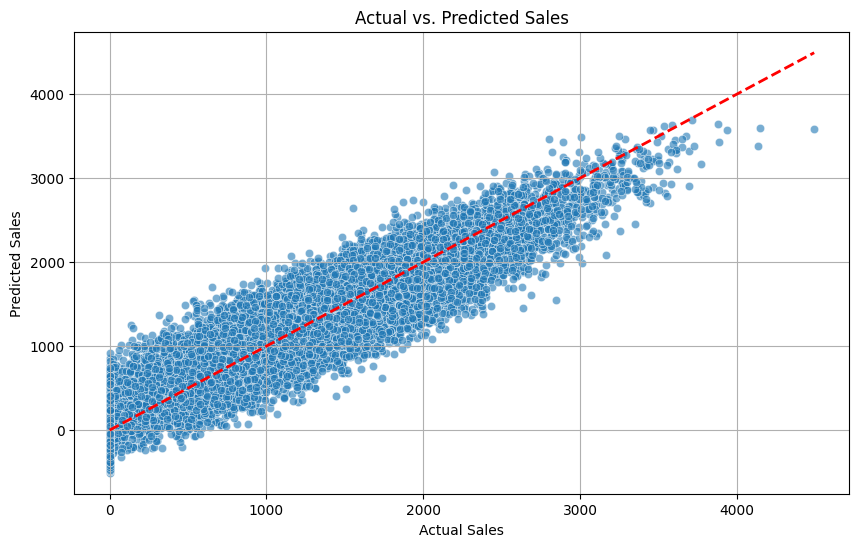

In [55]:
# Create a DataFrame for easier plotting
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=predictions_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Line for perfect prediction
plt.title('Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True)
plt.show()

### Analyze Residuals

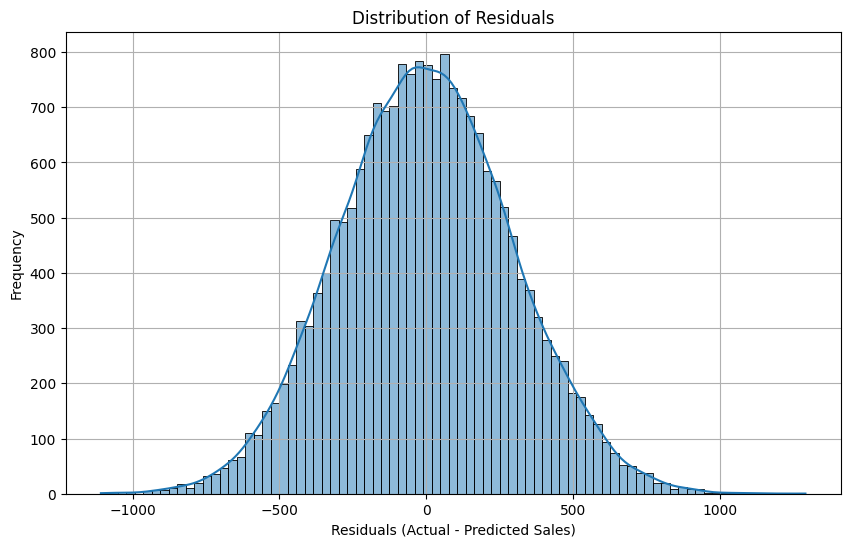

In [56]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted Sales)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The histogram looks roughly bell-shaped and centered around zero, it suggests that the model's errors are random and normally distributed.

Any significant skewness or multiple peaks could indicate that the model is missing important patterns or that there are subgroups in your data it struggles with.

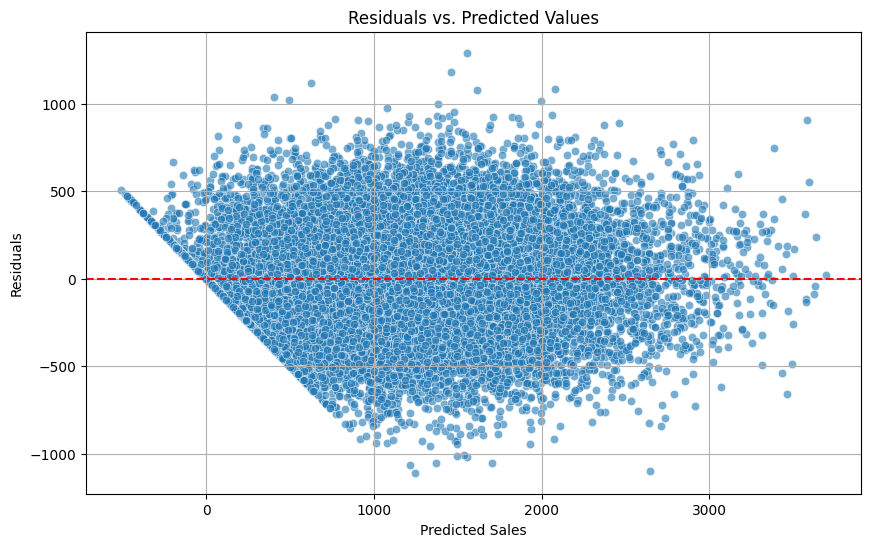

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

This scatter plot helps us check for patterns in the errors. The x-axis represents the predicted sales values, and the y-axis represents the residuals.

Ideally, for a well-fitting model, you want to see no discernible pattern in this plot. The points should be randomly scattered around the horizontal line at zero.

NB: Random scatter around zero (ideal): This indicates that the model's errors are independent of the predicted values, and the linear model is appropriate.

#**Random Forest Model**

**Step 1: Build the Model**

In [66]:
rfm = RandomForestRegressor(n_estimators=100, random_state=42)
rfm

RandomForestRegressor(random_state=42)

Note these:
1. RandomForestRegressor(...)
This is the algorithm itself. Instead of relying on just one complex decision tree—which is highly prone to overfitting—a Random Forest creates an entire "forest" of different, independent decision trees.

2.n_estimators=100 (The Number of Trees)
This parameter controls the size of your forest.

What it does: It tells the algorithm to build exactly 100 independent decision trees behind the scenes.

Why it matters: Generally, adding more trees makes the model more stable and reduces errors because the average of 100 or 200 trees cancels out the random mistakes of any single tree.

The Trade-off: There is a point of diminishing returns. Building 1,000 trees instead of 100 might make the model slightly more accurate, but it will consume significantly more computer memory (RAM) and take much longer to train within your pipeline. 100 is the standard enterprise baseline.

3. By setting random_state=42, you are providing a "seed" number for the computer's random number generator. It forces the computer to use the exact same sequence of randomness every single time.

Why the number 42? There is no mathematical magic to the number 42; it is simply a famous pop-culture joke in the technology community (from The Hitchhiker's Guide to the Galaxy). You could change it to random_state=7, 100, or 2026, and it would work exactly the same way. The only thing that matters is that the number stays constant so that your data experiments yield identical, trustworthy results across every run.

**Step 2: Fit Model into train dataset**

In [69]:
rfm.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Step 3: Make Prediction with the Model trained**

In [70]:
y_pred_rfm = rfm.predict(X_test)
y_pred_rfm

array([1102.72522142,  899.33121332, 1165.80918171, ...,  350.52552758,
       2049.76297058, 1061.39026234])

**Step 4: Evaluate the performance of the Model**

In [75]:
r2s_rfm = r2_score(y_test, y_pred_rfm)
mse_rfm = mean_squared_error(y_test, y_pred_rfm)
print(f"r2_score: {r2s_rfm:2f} ")
print(f"Mean Squared Error: {mse:.2f}")
rmse_rfm = np.sqrt(mse_rfm)
print(f"Root Mean Squared Error_rfm: {rmse_rfm:.2f}")

r2_score: 0.816672 
Mean Squared Error: 92343.89
Root Mean Squared Error_rfm: 303.88


import numpy as np
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

In [ ]:
import numpy as np
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

Root Mean Squared Error: 294.72


**Step 5: Compare Model Performance**

A. Result of Linear regression model

r_squared_score 0.827563
Mean Squared Error: 86857.90
Root Mean Squared Error: 294.72

B. Result of Random Forest regression model

r2_score: 0.816672
Mean Squared Error: 92343.89
Root Mean Squared Error_rfm: 303.88

#So far Linear Regressor Model performed more better than the Random Forest Model

#**Working with Decison Tree Model**

In [76]:
from sklearn.tree import DecisionTreeRegressor

**Step 1: Build the Model**

In [77]:
dtr = DecisionTreeRegressor(random_state=42)
dtr

DecisionTreeRegressor(random_state=42)

**Step 2: Fit model into dataset i.e., train model with data**

In [78]:
dtr.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

**Step 3: Make Prediction wih the Model**

In [80]:
y_pred_dtr = dtr.predict(X_test)
y_pred_dtr

array([ 806.82139029,  657.68075722, 1028.95385289, ...,  320.06812149,
       2312.75473091,  694.91561404])

**Step 4: Evaluate the Model**

In [83]:
r2s_dtr = r2_score(y_test, y_pred_dtr)
mse_dtr = mean_squared_error(y_test, y_pred_dtr)
print(f"r2_score: {r2s_dtr:2f} ")
print(f"Mean Squared Error: {mse_dtr:.2f}")
rmse_dtr = np.sqrt(mse_dtr)
print(f"Root Mean Squared Error_dtr: {rmse_dtr:.2f}")

r2_score: 0.634416 
Mean Squared Error: 184147.73
Root Mean Squared Error_dtr: 429.12


#**Project Summary**

**My First AI Sales Prediction Project!**

Hey there! So, I've been learning about AI and machine learning, and I just finished my first project where I tried to predict sales! It was super cool.

Here's what I did:

Getting the Data Ready: First, I connected my Google Drive to Colab to get my sales data. It was in a big CSV file called large_sales_dataset.csv. I loaded it up with pandas and made sure everything looked good: checked how many rows and columns there were, looked for any missing data (luckily there wasn't any!), and made sure there were no duplicate entries. I also separated my Sales column, which is what I want to predict, from all the other columns like Store_ID, Price, and Marketing_Spend.

Splitting the Data: Before building any models, I split my data into two parts: a 'training' set (what my models learn from) and a 'testing' set (what I use to see how well they learned). This is important so the models don't just memorize the data.

Trying Out Different Models: This was the fun part! I tried three different types of prediction models:

Linear Regression: This is like drawing a straight line through the data to find patterns. It's a pretty basic one, but it did surprisingly well! It got an R-squared score of about 0.83, which means it could explain 83% of the sales variations, and its average error (RMSE) was around 295.

Random Forest Regressor: This one is a bit more advanced. It uses a 'forest' of many small decision-making 'trees' to make predictions. It also performed quite well, with an R-squared of 0.82 and an RMSE of 304. It was a close second!

Decision Tree Regressor: This model makes decisions like a flowchart. It had an R-squared of 0.63 and a higher RMSE of 429. It seems this single tree didn't do as well as the 'forest' of trees or the simple linear model.

Checking How Well They Did: For each model, I looked at numbers like R-squared (how much of the sales variation the model explained) and Root Mean Squared Error (RMSE) (how far off the predictions were, on average).

I also made some cool plots to see actual sales versus predicted sales and looked at the 'residuals' (the errors) to make sure there were no weird patterns.

My Conclusion So Far:

It looks like the Linear Regression model was actually the best performer in this project! It had the highest R-squared and the lowest RMSE, meaning it was the most accurate at predicting sales among the ones I tried.

This project showed me how to prepare data, train different models, and then figure out which one is the best for a specific task. I'm excited to learn more!